# git clone

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/junnokimm/wafer-map-defect-xai.git

Cloning into 'wafer-map-defect-xai'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 9 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.


In [3]:
%cd /content/wafer-map-defect-xai

/content/wafer-map-defect-xai


# 데이터 파일 경로 확인

In [4]:
import os

DATA_PATH = "/content/drive/MyDrive/wafer-map-defect-xai/data/raw/LSWMD.pkl"

print(os.path.exists(DATA_PATH))

True


## 데이터 로드

In [5]:
import pandas as pd

df = pd.read_pickle(DATA_PATH)

print(df.shape)
df.head()

(811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [7]:
df.columns

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

In [8]:
df["failureType"].head(20)

,failureType
0,[[none]]
1,[[none]]
2,[[none]]
3,[[none]]
4,[[none]]
5,[[none]]
6,[[none]]
7,[[none]]
8,[[none]]
9,[[none]]


In [9]:
def extract_label(x):
    try:
        if len(x) == 0:
            return None
        return x[0][0]
    except:
        return None

df["label"] = df["failureType"].apply(extract_label)

In [10]:
df["label"].head(20)

,label
0,none
1,none
2,none
3,none
4,none
5,none
6,none
7,none
8,none
9,none


In [11]:
df["label"].value_counts(dropna=False)

,count
label,
None,638507
none,147431
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555


In [12]:
labeled_df = df[df["label"].notnull()].copy()

print(labeled_df.shape)
labeled_df["label"].value_counts()

(172950, 7)


,count
label,
none,147431
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


# 클래스 분포 확인

In [13]:
label_counts = labeled_df["label"].value_counts()
label_counts

,count
label,
none,147431
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


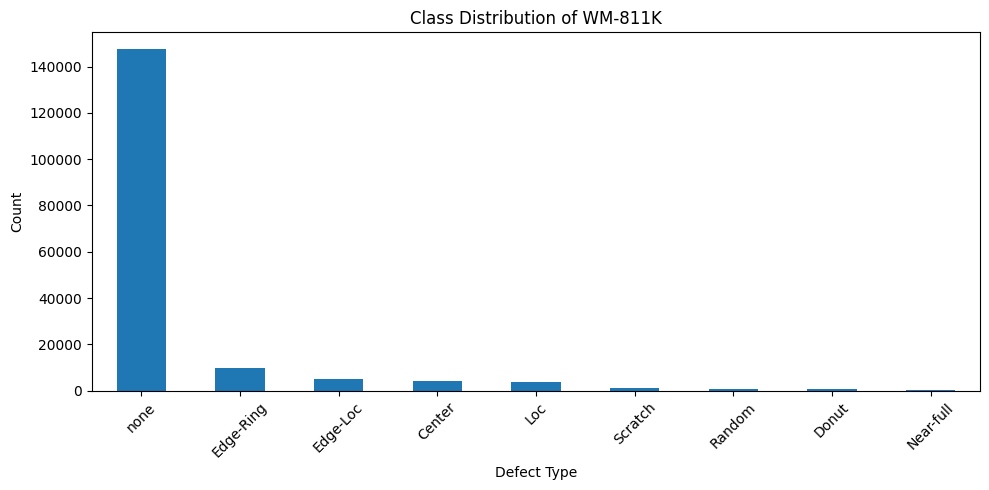

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Class Distribution of WM-811K")
plt.xlabel("Defect Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

WM-811K 데이터셋은 결함 유형별 샘플 수 차이가 커서 클래스 불균형 문제가 존재한다.

# 라벨별 비율 확인

In [15]:
label_ratio = labeled_df["label"].value_counts(normalize=True) * 100
label_ratio.round(2)

,proportion
label,
none,85.24
Edge-Ring,5.60
Edge-Loc,3.00
Center,2.48
Loc,2.08
Scratch,0.69
Random,0.50
Donut,0.32
Near-full,0.09


# 결함 유형별 웨이퍼 맵 샘플 보기

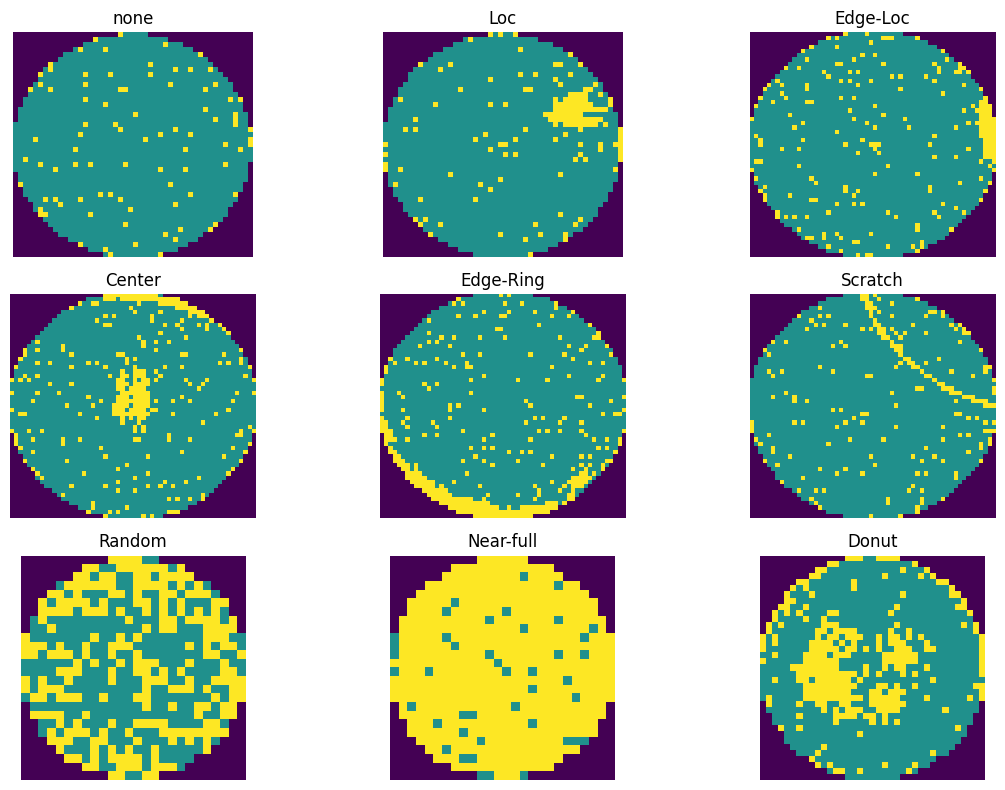

In [16]:
import matplotlib.pyplot as plt

classes = labeled_df["label"].unique()

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    sample = labeled_df[labeled_df["label"] == cls].iloc[0]
    wafer_map = sample["waferMap"]

    plt.subplot(3, 3, i + 1)
    plt.imshow(wafer_map)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 웨이퍼맵 크기 확인

In [17]:
labeled_df["map_shape"] = labeled_df["waferMap"].apply(lambda x: x.shape)
labeled_df["map_shape"].value_counts().head(20)

,count
map_shape,
"(25, 27)",18781
"(26, 26)",14366
"(30, 34)",12400
"(29, 26)",11751
"(27, 25)",10682
"(39, 37)",10173
"(33, 29)",8125
"(42, 44)",6724
"(44, 41)",6134


# 웨이퍼맵 값 확인

In [18]:
import numpy as np

sample_map = labeled_df["waferMap"].iloc[0]
np.unique(sample_map)

array([0, 1, 2], dtype=uint8)

0 = wafer 밖 영역
1 = 정상 die
2 = 불량 die

# 라벨 인코딩
문자 라벨을 숫자로 바꾸기

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labeled_df["label_encoded"] = le.fit_transform(labeled_df["label"])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping

{np.str_('Center'): np.int64(0),
 np.str_('Donut'): np.int64(1),
 np.str_('Edge-Loc'): np.int64(2),
 np.str_('Edge-Ring'): np.int64(3),
 np.str_('Loc'): np.int64(4),
 np.str_('Near-full'): np.int64(5),
 np.str_('Random'): np.int64(6),
 np.str_('Scratch'): np.int64(7),
 np.str_('none'): np.int64(8)}

이 매핑 꼭 저장해두기


# 웨이퍼맵을 64x64로 리사이즈

In [20]:
import numpy as np
from skimage.transform import resize

리사이즈함수

In [21]:
def resize_wafer_map(wafer_map, target_size=(64, 64)):
    resized = resize(
        wafer_map,
        target_size,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    )
    return resized.astype(np.float32)

In [22]:
X = np.stack(labeled_df["waferMap"].apply(resize_wafer_map).values)
y = labeled_df["label_encoded"].values

print(X.shape)
print(y.shape)

(172950, 64, 64)
(172950,)


# CNN용 채널 차원 추가
(높이, 너비, 채널)

In [23]:
X = X[..., np.newaxis]

print(X.shape)

(172950, 64, 64, 1)


# Train / Validation / Test 분리

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (121065, 64, 64, 1) (121065,)
Val: (25942, 64, 64, 1) (25942,)
Test: (25943, 64, 64, 1) (25943,)


In [25]:
import os

SAVE_DIR = "/content/drive/MyDrive/wafer-map-defect-xai/data/processed"
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(f"{SAVE_DIR}/X_train.npy", X_train)
np.save(f"{SAVE_DIR}/X_val.npy", X_val)
np.save(f"{SAVE_DIR}/X_test.npy", X_test)

np.save(f"{SAVE_DIR}/y_train.npy", y_train)
np.save(f"{SAVE_DIR}/y_val.npy", y_val)
np.save(f"{SAVE_DIR}/y_test.npy", y_test)

np.save(f"{SAVE_DIR}/classes.npy", le.classes_)

print("Saved preprocessed data!")

Saved preprocessed data!


In [26]:
os.listdir(SAVE_DIR)

['X_train.npy',
 'X_val.npy',
 'X_test.npy',
 'y_train.npy',
 'y_val.npy',
 'y_test.npy',
 'classes.npy']